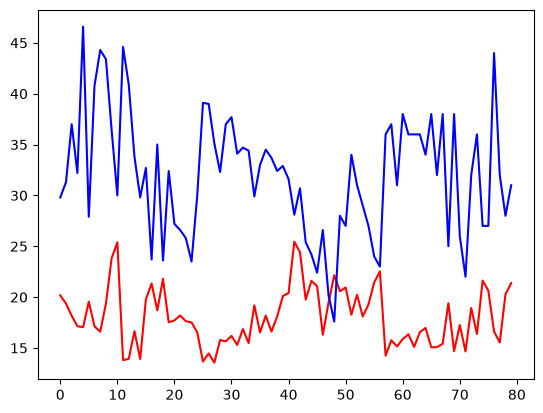

In [29]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import torch
import matplotlib.pyplot as plt

auto_mpg = fetch_ucirepo(id=9)
X = auto_mpg.data.features
y = auto_mpg.data.targets
df = pd.DataFrame(X)
target = pd.DataFrame(y)
split = int(target.shape[0]*0.80)
df["horsepower"] = df["horsepower"].fillna(df["horsepower"].mean())
displacement_train = torch.tensor(df["displacement"].values[:split], dtype=torch.float32)
cylinders_train = torch.tensor(df["cylinders"].values[:split], dtype=torch.float32)
horsepower_train = torch.tensor(df["horsepower"].values[:split], dtype = torch.float32)
weight_train = torch.tensor(df["weight"].values[:split], dtype=torch.float32)
acceleration_train = torch.tensor(df["acceleration"].values[:split], dtype=torch.float32)
Y_train = torch.tensor(target["mpg"].values[:split], dtype = torch.float32)
displacement_test = torch.tensor(df["displacement"].values[split:], dtype=torch.float32)
cylinders_test = torch.tensor(df["cylinders"].values[split:], dtype=torch.float32)
horsepower_test = torch.tensor(df["horsepower"].values[split:], dtype = torch.float32)
weight_test = torch.tensor(df["weight"].values[split:], dtype=torch.float32)
acceleration_test = torch.tensor(df["acceleration"].values[split:], dtype=torch.float32)
Y_test = torch.tensor(target["mpg"].values[split:], dtype = torch.float32)
w1 = torch.tensor(0.0, requires_grad=True)
w2 = torch.tensor(0.0, requires_grad=True)
w3 = torch.tensor(0.0, requires_grad=True)
w4 = torch.tensor(0.0, requires_grad=True)
w5 = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)
epochs = 100000
learning_rate = 0.000000001
loss_plot = []
for i in range(epochs):
    y_pred = displacement_train*w1 + cylinders_train*w2 + horsepower_train*w3 + weight_train*w4 + acceleration_train*w5 + b
    
    loss = ((y_pred-Y_train)**2).mean()
    
    loss_plot.append(loss.item())
    loss.backward()
    
    with torch.no_grad():
        w1 -= learning_rate*w1.grad
        w2 -= learning_rate*w2.grad
        w3 -= learning_rate*w3.grad
        w4 -= learning_rate*w4.grad
        w5 -= learning_rate*w5.grad
        b -= learning_rate*b.grad
    
    w1.grad = None
    w2.grad = None
    w3.grad = None
    w4.grad = None
    w5.grad = None
    b.grad = None

Y_predictions = w1*displacement_test + w2*cylinders_test + w3*horsepower_test + w4*weight_test + w5*acceleration_test + b
plt.plot(Y_predictions.detach().numpy(), color='red')
plt.plot(Y_test.detach().numpy(), color='blue')
plt.show()
